In [1]:
# need Microsoft Visual C++ for running torchvision on windows
import sys
import subprocess

# Check if VC++ is installed
result = subprocess.run(
    ["powershell", "-Command", 
     "Get-WmiObject -Class Win32_Product | Where-Object {$_.Name -like '*Microsoft Visual C++*'} | Select-Object Name, Version"],
    capture_output=True, text=True
)
print(result.stdout)


Name                                                          Version   
----                                                          -------   
Microsoft Visual C++ 2010  x64 Redistributable - 10.0.40219   10.0.40219
Microsoft Visual C++ 2013 x86 Minimum Runtime - 12.0.40664    12.0.40664
Microsoft Visual C++ 2010  x86 Redistributable - 10.0.40219   10.0.40219
Microsoft Visual C++ 2013 x64 Additional Runtime - 12.0.21005 12.0.21005
Microsoft Visual C++ 2013 x64 Minimum Runtime - 12.0.21005    12.0.21005
Microsoft Visual C++ 2012 x64 Additional Runtime - 11.0.61030 11.0.61030
Microsoft Visual C++ 2022 X86 Minimum Runtime - 14.51.36231   14.51.3...
Microsoft Visual C++ 2022 X64 Minimum Runtime - 14.51.36231   14.51.3...
Microsoft Visual C++ 2022 X86 Additional Runtime - 14.51.3... 14.51.3...
Microsoft Visual C++ 2012 x86 Additional Runtime - 11.0.61030 11.0.61030
Microsoft Visual C++ 2012 x64 Minimum Runtime - 11.0.61030    11.0.61030
Microsoft Visual C++ 2022 X64 Additional Runtime -

In [2]:
# verifying kernel is using virtualenv (for a cleaner approach and avoiding OSErrors)
import sys
print(sys.executable)

H:\ai-ml\exercise\ai-ml-exercises\.venv\Scripts\python.exe


In [5]:
import torch
import torchvision

print(f"PyTorch version: {torch.__version__}")
print('torchvision:', torchvision.__version__)

PyTorch version: 2.13.0+cpu
torchvision: 0.28.0+cpu


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
print("\n" + "="*60)
print("LOADING MNIST DATA")
print("="*60)

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Download and load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders (for batching)
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of batches (train): {len(train_loader)}")
print(f"Number of batches (test): {len(test_loader)}")


LOADING MNIST DATA
Training samples: 60000
Test samples: 10000
Batch size: 64
Number of batches (train): 938
Number of batches (test): 157



EXPLORING THE DATA


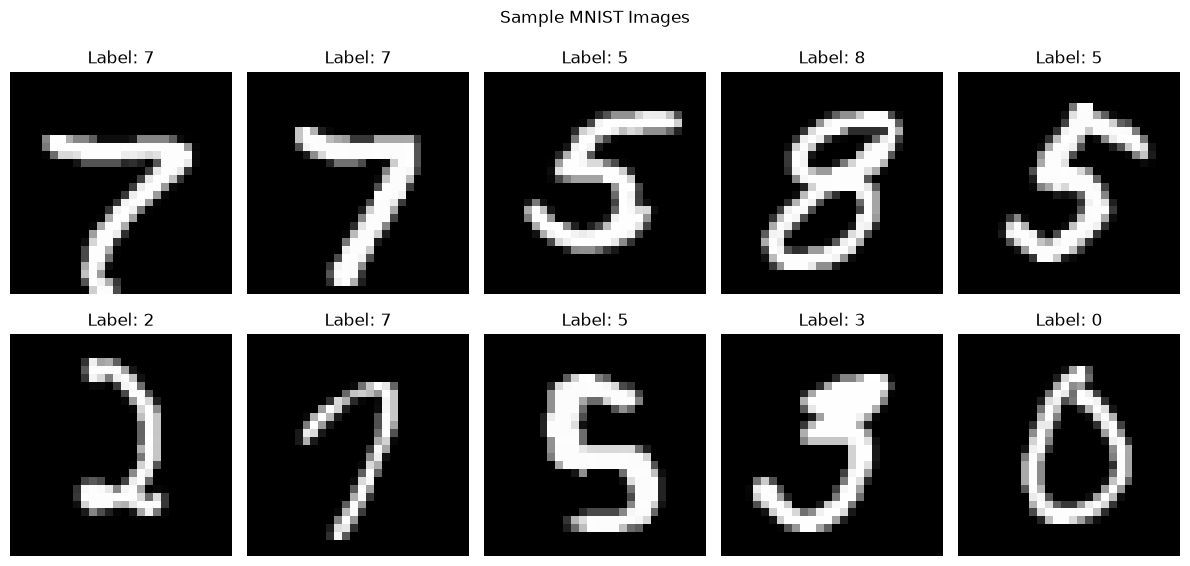

Image shape: torch.Size([1, 28, 28])
Label range: 0 to 9


In [13]:
print("\n" + "="*60)
print("EXPLORING THE DATA")
print("="*60)

# Get a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show some images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(f'Label: {labels[i].item()}')
    axes[i].axis('off')

plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

print(f"Image shape: {images[0].shape}")  # [1, 28, 28] = 1 channel, 28x28 pixels
print(f"Label range: {labels.min().item()} to {labels.max().item()}")


In [14]:
print("\n" + "="*60)
print("DESIGNING THE NEURAL NETWORK")
print("="*60)

class MNISTClassifier(nn.Module):
    """
    A simple neural network for MNIST digit classification
    """
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        
        # Flatten layer: 28x28 = 784 pixels
        self.flatten = nn.Flatten()
        
        # Hidden layers
        self.layer1 = nn.Linear(28*28, 128)  # 784 → 128 (based on experience and test we determine 128)
        self.activation1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)      # Prevent overfitting
        
        self.layer2 = nn.Linear(128, 64)     # 128 → 64 (based on experience and test we determine 64)
        self.activation2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        
        # Output layer: 10 classes (digits 0-9)
        self.layer3 = nn.Linear(64, 10)
        # No activation - will use CrossEntropyLoss which has softmax built-in
    
    def forward(self, x):
        x = self.flatten(x)
        
        x = self.layer1(x)
        x = self.activation1(x)
        x = self.dropout1(x)
        
        x = self.layer2(x)
        x = self.activation2(x)
        x = self.dropout2(x)
        
        x = self.layer3(x)  # No softmax - CrossEntropyLoss handles it
        return x

# Create model
model = MNISTClassifier()
print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


DESIGNING THE NEURAL NETWORK
Model Architecture:
MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (activation1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (activation2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (layer3): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 109,386
Trainable parameters: 109,386


In [15]:
print("\n" + "="*60)
print("TRAINING THE NEURAL NETWORK")
print("="*60)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # For multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
train_losses = []
train_accuracies = []
test_accuracies = []

print("Starting training...")
for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Calculate training accuracy
    train_accuracy = 100 * correct / total
    train_accuracies.append(train_accuracy)
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Evaluation phase (on test set)
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    
    test_accuracy = 100 * correct_test / total_test
    test_accuracies.append(test_accuracy)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Test Acc: {test_accuracy:.2f}%")

print("\n✅ Training complete!")


TRAINING THE NEURAL NETWORK
Starting training...
Epoch 1/10 - Loss: 0.4898, Train Acc: 84.88%, Test Acc: 93.42%
Epoch 2/10 - Loss: 0.2495, Train Acc: 92.40%, Test Acc: 94.87%
Epoch 3/10 - Loss: 0.2047, Train Acc: 93.97%, Test Acc: 95.64%
Epoch 4/10 - Loss: 0.1813, Train Acc: 94.50%, Test Acc: 96.19%
Epoch 5/10 - Loss: 0.1675, Train Acc: 94.81%, Test Acc: 96.53%
Epoch 6/10 - Loss: 0.1561, Train Acc: 95.32%, Test Acc: 96.71%
Epoch 7/10 - Loss: 0.1447, Train Acc: 95.62%, Test Acc: 96.83%
Epoch 8/10 - Loss: 0.1366, Train Acc: 95.79%, Test Acc: 97.12%
Epoch 9/10 - Loss: 0.1354, Train Acc: 95.75%, Test Acc: 97.16%
Epoch 10/10 - Loss: 0.1302, Train Acc: 95.90%, Test Acc: 97.07%

✅ Training complete!



ANALYZING TRAINING PROGRESS


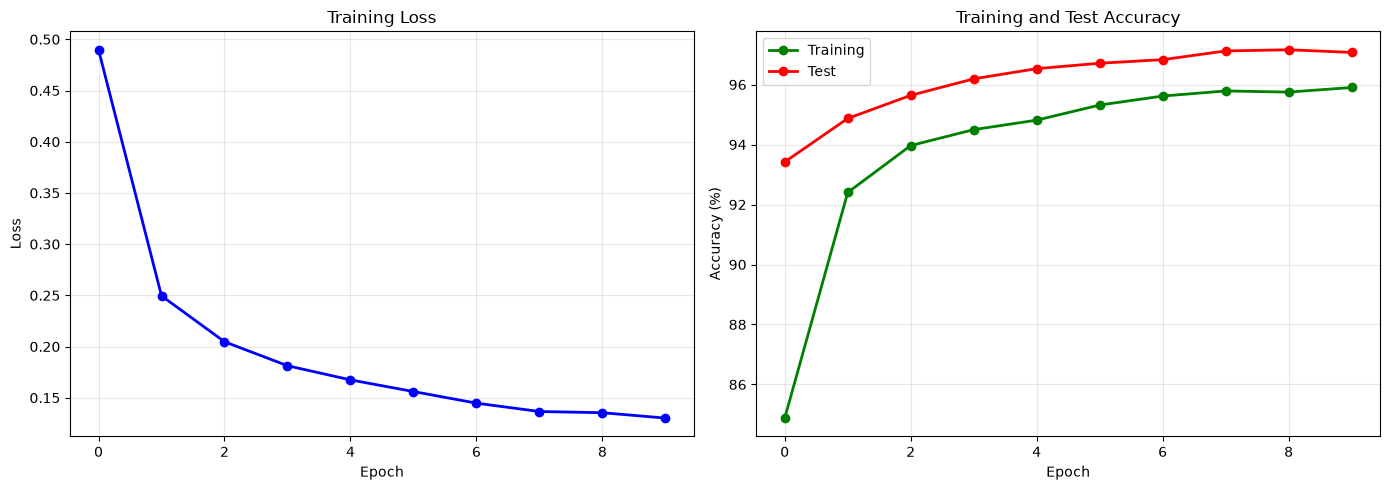

In [16]:
print("\n" + "="*60)
print("ANALYZING TRAINING PROGRESS")
print("="*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
ax1.plot(train_losses, 'bo-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy
ax2.plot(train_accuracies, 'go-', linewidth=2, label='Training')
ax2.plot(test_accuracies, 'ro-', linewidth=2, label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Get all predictions
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

           0     0.9729    0.9898    0.9813       980
           1     0.9886    0.9921    0.9903      1135
           2     0.9746    0.9661    0.9703      1032
           3     0.9601    0.9762    0.9681      1010
           4     0.9618    0.9745    0.9681       982
           5     0.9547    0.9686    0.9616       892
           6     0.9750    0.9781    0.9766       958
           7     0.9608    0.9767    0.9686      1028
           8     0.9828    0.9374    0.9595       974
           9     0.9734    0.9445    0.9588      1009

    accuracy                         0.9707     10000
   macro avg     0.9705    0.9704    0.9703     10000
weighted avg     0.9708    0.9707    0.9707     10000


Confusion Matrix:
[[ 970    0    1    0    0    3    3    1    2    0]
 [   0 1126    0    4    0    0    2    0    3    0]
 [   8    2  997    5    2    0    3   10    5    0]
 [   0    0    7  986


VISUALIZING PREDICTIONS


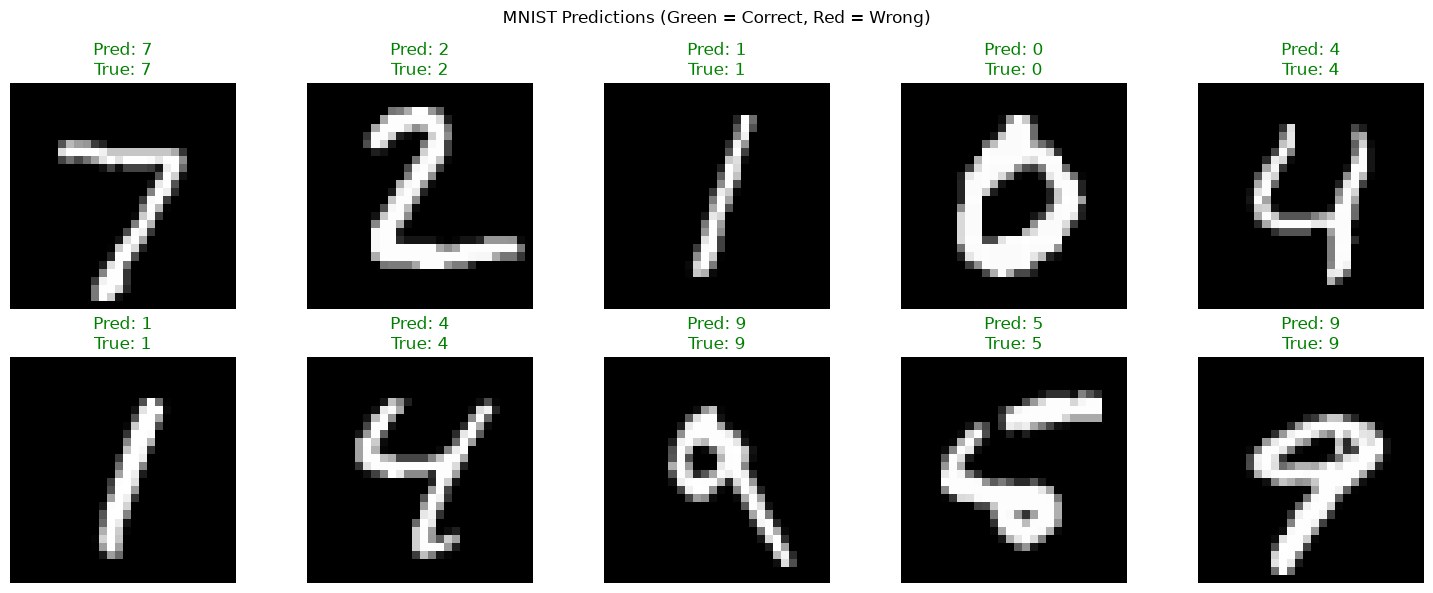


Sample 0: True label = 7
Confidence scores for each digit:
  0: 0.00%
  1: 0.00%
  2: 0.02%
  3: 0.01%
  4: 0.00%
  5: 0.00%
  6: 0.00%
  7: 99.97%
  8: 0.00%
  9: 0.00%


In [20]:
print("\n" + "="*60)
print("VISUALIZING PREDICTIONS")
print("="*60)

# Get some test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Get predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Show images with predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i][0], cmap='gray')
    pred = predicted[i].item()
    true = labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'Pred: {pred}\nTrue: {true}', color=color)
    axes[i].axis('off')

plt.suptitle('MNIST Predictions (Green = Correct, Red = Wrong)')
plt.tight_layout()
plt.show()

# Show confidence scores for one sample
sample_idx = 0
with torch.no_grad():
    output = model(images[sample_idx].unsqueeze(0))
    probabilities = torch.softmax(output, dim=1).squeeze().numpy()

print(f"\nSample {sample_idx}: True label = {labels[sample_idx].item()}")
print("Confidence scores for each digit:")
for i, prob in enumerate(probabilities):
    print(f"  {i}: {prob*100:.2f}%")

PREDICTION ANALYSIS
Total correct: 9707
Total wrong: 293
Accuracy: 97.07%

✅ Highest confidence correct: 100.0%
❌ Lowest confidence wrong: 100.0%


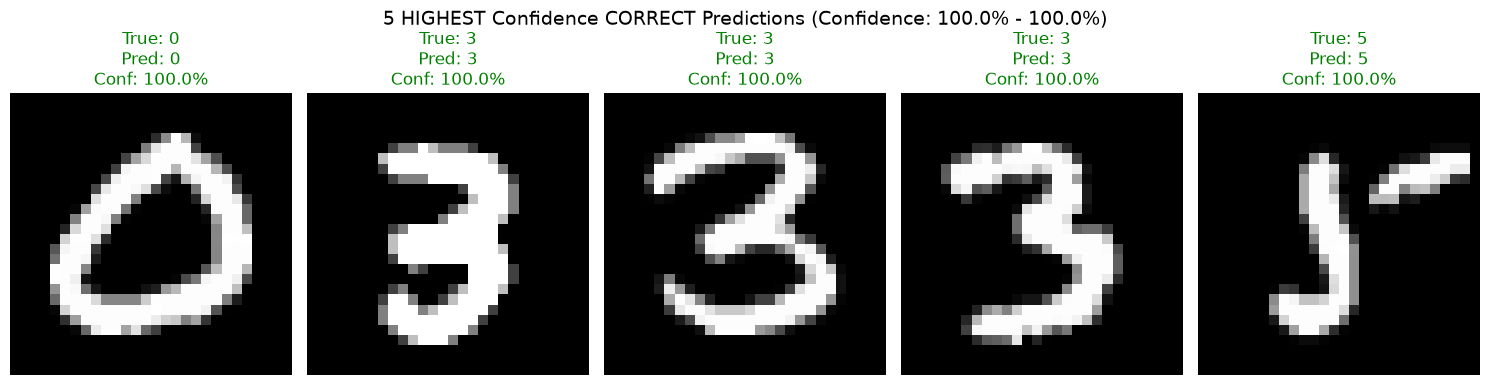

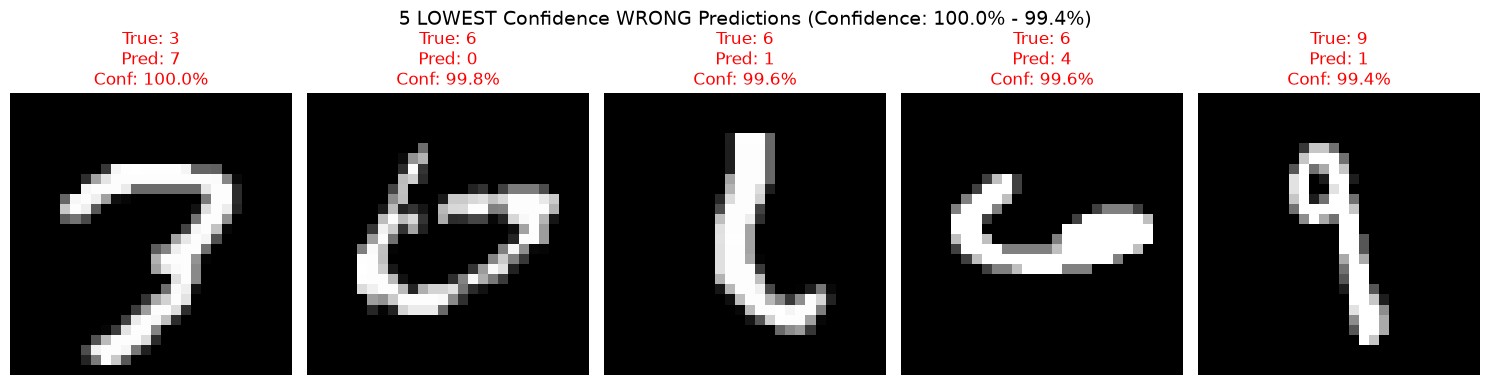


DETAILED RESULTS

✅ 5 HIGHEST CONFIDENCE CORRECT PREDICTIONS:
  1. True: 0 → Pred: 0 (Confidence: 100.0%)
  2. True: 3 → Pred: 3 (Confidence: 100.0%)
  3. True: 3 → Pred: 3 (Confidence: 100.0%)
  4. True: 3 → Pred: 3 (Confidence: 100.0%)
  5. True: 5 → Pred: 5 (Confidence: 100.0%)

❌ 5 HIGHEST CONFIDENCE WRONG PREDICTIONS:
  1. True: 3 → Pred: 7 (Confidence: 100.0%)
  2. True: 6 → Pred: 0 (Confidence: 99.8%)
  3. True: 6 → Pred: 1 (Confidence: 99.6%)
  4. True: 6 → Pred: 4 (Confidence: 99.6%)
  5. True: 9 → Pred: 1 (Confidence: 99.4%)


In [26]:
# Collect all predictions with their confidence scores
model.eval()
correct_predictions = []
wrong_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        for i in range(len(images)):
            sample = {
                'image': images[i],
                'true': labels[i].item(),
                'pred': predicted[i].item(),
                'confidence': probabilities[i][predicted[i]].item()
            }
            
            if predicted[i] == labels[i]:
                correct_predictions.append(sample)
            else:
                wrong_predictions.append(sample)

# Sort by confidence
correct_predictions.sort(key=lambda x: x['confidence'], reverse=True)  # Highest first
wrong_predictions.sort(key=lambda x: x['confidence'], reverse=True)  # Highest first

# Get top 5 highest confidence correct and top 5 lowest confidence wrong
top_5_correct = correct_predictions[:5]
top_5_wrong = wrong_predictions[:5]

# Display function
def show_predictions(predictions, title, color='green'):
    """Display predictions in a row."""
    if not predictions:
        print(f"No predictions to show for: {title}")
        return
    
    n = len(predictions)
    fig, axes = plt.subplots(1, n, figsize=(15, 4))
    if n == 1:
        axes = [axes]
    
    for i, sample in enumerate(predictions):
        axes[i].imshow(sample['image'][0], cmap='gray')
        is_correct = sample['true'] == sample['pred']
        color = 'green' if is_correct else 'red'
        axes[i].set_title(
            f"\nTrue: {sample['true']}\nPred: {sample['pred']}\nConf: {sample['confidence']*100:.1f}%",
            color=color
        )
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# summary
print("="*60)
print("PREDICTION ANALYSIS")
print("="*60)
print(f"Total correct: {len(correct_predictions)}")
print(f"Total wrong: {len(wrong_predictions)}")
print(f"Accuracy: {len(correct_predictions)/(len(correct_predictions)+len(wrong_predictions))*100:.2f}%")

if correct_predictions:
    print(f"\n✅ Highest confidence correct: {top_5_correct[0]['confidence']*100:.1f}%")
if wrong_predictions:
    print(f"❌ Lowest confidence wrong: {top_5_wrong[0]['confidence']*100:.1f}%")

# Display results
if correct_predictions:
    show_predictions(
        top_5_correct,
        f"5 HIGHEST Confidence CORRECT Predictions (Confidence: {top_5_correct[0]['confidence']*100:.1f}% - {top_5_correct[-1]['confidence']*100:.1f}%)",
        color='green'
    )

if wrong_predictions:
    show_predictions(
        top_5_wrong,
        f"5 LOWEST Confidence WRONG Predictions (Confidence: {top_5_wrong[0]['confidence']*100:.1f}% - {top_5_wrong[-1]['confidence']*100:.1f}%)",
        color='red'
    )

# Print details
print("\n" + "="*60)
print("DETAILED RESULTS")
print("="*60)

print("\n✅ 5 HIGHEST CONFIDENCE CORRECT PREDICTIONS:")
for i, sample in enumerate(top_5_correct, 1):
    print(f"  {i}. True: {sample['true']} → Pred: {sample['pred']} (Confidence: {sample['confidence']*100:.1f}%)")

if wrong_predictions:
    print("\n❌ 5 HIGHEST CONFIDENCE WRONG PREDICTIONS:")
    for i, sample in enumerate(top_5_wrong, 1):
        print(f"  {i}. True: {sample['true']} → Pred: {sample['pred']} (Confidence: {sample['confidence']*100:.1f}%)")
else:
    print("\n🎉 No wrong predictions! Perfect model!")

In [27]:
print("\n" + "="*60)
print("SAVING AND LOADING THE MODEL")
print("="*60)

# Save model
torch.save(model.state_dict(), 'mnist_model.pth')
print("✅ Model saved as 'mnist_model.pth'")

# Load model
new_model = MNISTClassifier()
new_model.load_state_dict(torch.load('mnist_model.pth'))
new_model.eval()
print("✅ Model loaded successfully")

# Verify loaded model
with torch.no_grad():
    output_original = model(images[:5])
    output_loaded = new_model(images[:5])
    are_equal = torch.allclose(output_original, output_loaded, atol=1e-6)
    print(f"Original vs Loaded model outputs: {are_equal} (should be True)")



SAVING AND LOADING THE MODEL
✅ Model saved as 'mnist_model.pth'
✅ Model loaded successfully
Original vs Loaded model outputs: True (should be True)
